In [1]:
!pip install -q sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.6 MB/s eta 0:00:00


In [2]:
import re, time, math, random, unicodedata, json, pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sacrebleu

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import files
print('Upload rus.txt ...')
uploaded = files.upload()
DATA_PATH = list(uploaded.keys())[0]
print(f'Loaded: {DATA_PATH}')

Upload rus.txt ...


Saving rus.txt to rus.txt
Loaded: rus.txt


In [4]:
MAX_LEN     = 12
NUM_SAMPLES = 50_000
MIN_FREQ    = 2
SEED        = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = '<PAD>', '<SOS>', '<EOS>', '<UNK>'
PAD_IDX,   SOS_IDX,   EOS_IDX,   UNK_IDX  =  0,      1,      2,       3

def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def normalize_en(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r'([.!?])', r' \1', s)
    s = re.sub(r'[^a-z.!?\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def normalize_ru(s):
    s = s.lower().strip()
    s = re.sub(r'([.!?,;:])', r' \1', s)
    s = re.sub(r'[^\u0400-\u04FFa-z.!?,;:\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

tokenize_en = lambda s: normalize_en(s).split()
tokenize_ru = lambda s: normalize_ru(s).split()

pairs = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            en_tok = tokenize_en(parts[0])
            ru_tok = tokenize_ru(parts[1])
            if 1 <= len(en_tok) <= MAX_LEN and 1 <= len(ru_tok) <= MAX_LEN:
                pairs.append((en_tok, ru_tok))

print(f'Total filtered pairs: {len(pairs):,}')
if NUM_SAMPLES and len(pairs) > NUM_SAMPLES:
    random.shuffle(pairs)
    pairs = pairs[:NUM_SAMPLES]
    print(f'Using {len(pairs):,} pairs')

for en, ru in pairs[:3]:
    print(f'  EN: {" ".join(en)}')
    print(f'  RU: {" ".join(ru)}')
    print()

Total filtered pairs: 349,886
Using 50,000 pairs
  EN: open up the door .
  RU: вскройте дверь .

  EN: i ve lost my purse again .
  RU: я опять потерял кошелёк .

  EN: tom walked away without waiting for an answer .
  RU: фома ушёл , не дожидаясь ответа .



In [5]:
class Vocab:
    def __init__(self, name):
        self.name = name
        self.word2idx = {t: i for i, t in enumerate([PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN])}
        self.idx2word = {i: t for i, t in enumerate([PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN])}

    def build(self, sentences, min_freq=MIN_FREQ):
        counter = Counter(w for sent in sentences for w in sent)
        for word, freq in sorted(counter.items()):
            if freq >= min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f'{self.name} vocab: {len(self.word2idx):,}')

    def encode(self, tokens):
        return [self.word2idx.get(t, UNK_IDX) for t in tokens]

    def decode(self, indices):
        return [self.idx2word.get(i, UNK_TOKEN) for i in indices]

    def __len__(self):
        return len(self.word2idx)

random.shuffle(pairs)
split = int(0.9 * len(pairs))
train_pairs, val_pairs = pairs[:split], pairs[split:]
print(f'Train: {len(train_pairs):,} | Val: {len(val_pairs):,}')

src_vocab = Vocab('EN'); tgt_vocab = Vocab('RU')
src_vocab.build([p[0] for p in train_pairs])
tgt_vocab.build([p[1] for p in train_pairs])

Train: 45,000 | Val: 5,000
EN vocab: 4,632
RU vocab: 9,332


In [6]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, sv, tv):
        self.data = []
        for src_tok, tgt_tok in pairs:
            self.data.append((
                sv.encode(src_tok) + [EOS_IDX],
                [SOS_IDX] + tv.encode(tgt_tok) + [EOS_IDX]
            ))
    def __len__(self):  return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    src_b, tgt_b = zip(*batch)
    ms = max(len(s) for s in src_b)
    mt = max(len(t) for t in tgt_b)
    src_p = torch.tensor([s + [PAD_IDX]*(ms-len(s)) for s in src_b], dtype=torch.long)
    tgt_p = torch.tensor([t + [PAD_IDX]*(mt-len(t)) for t in tgt_b], dtype=torch.long)
    return src_p, tgt_p

BATCH_SIZE = 128
train_loader = DataLoader(TranslationDataset(train_pairs, src_vocab, tgt_vocab),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TranslationDataset(val_pairs,   src_vocab, tgt_vocab),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 352 | Val batches: 40


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, cell_type):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop      = nn.Dropout(dropout)
        cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[self.cell_type]
        self.rnn = cls(embed_dim, hidden_dim, n_layers,
                       dropout=dropout if n_layers > 1 else 0, batch_first=True)

    def forward(self, src):
        return self.rnn(self.drop(self.embedding(src)))

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout, cell_type):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.vocab_size = vocab_size
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.drop       = nn.Dropout(dropout)
        cls = {'rnn': nn.RNN, 'lstm': nn.LSTM, 'gru': nn.GRU}[self.cell_type]
        self.rnn    = cls(embed_dim, hidden_dim, n_layers,
                          dropout=dropout if n_layers > 1 else 0, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token, hidden):
        emb = self.drop(self.embedding(token.unsqueeze(1)))
        out, hidden = self.rnn(emb, hidden)
        return self.fc_out(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, src_vs, tgt_vs, embed_dim=256, hidden_dim=512,
                 n_layers=2, dropout=0.3, cell_type='lstm'):
        super().__init__()
        self.encoder = Encoder(src_vs, embed_dim, hidden_dim, n_layers, dropout, cell_type)
        self.decoder = Decoder(tgt_vs, embed_dim, hidden_dim, n_layers, dropout, cell_type)

    def forward(self, src, tgt, tf_ratio=0.5):
        B, Tt = tgt.shape
        V     = self.decoder.vocab_size
        _, hidden = self.encoder(src)
        dec_in  = tgt[:, 0]
        outputs = torch.zeros(B, Tt-1, V).to(src.device)
        for t in range(1, Tt):
            logits, hidden = self.decoder(dec_in, hidden)
            outputs[:, t-1] = logits
            dec_in = tgt[:, t] if random.random() < tf_ratio else logits.argmax(-1)
        return outputs

print('Model defined OK')

Model defined OK


In [8]:
def train_epoch(model, loader, opt, criterion, clip=1.0):
    model.train(); total = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        opt.zero_grad()
        out = model(src, tgt)
        B, T, V = out.shape
        loss = criterion(out.reshape(B*T, V), tgt[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval(); total = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        out = model(src, tgt, tf_ratio=0.0)
        B, T, V = out.shape
        loss = criterion(out.reshape(B*T, V), tgt[:, 1:].reshape(-1))
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def translate(model, src_tokens, max_len=50):
    model.eval()
    ids = src_vocab.encode(src_tokens) + [EOS_IDX]
    src = torch.tensor([ids], dtype=torch.long).to(device)
    _, hidden = model.encoder(src)
    token, result = torch.tensor([SOS_IDX]).to(device), []
    for _ in range(max_len):
        logits, hidden = model.decoder(token, hidden)
        token = logits.argmax(-1)
        idx = token.item()
        if idx == EOS_IDX: break
        result.append(tgt_vocab.idx2word.get(idx, UNK_TOKEN))
    return result

@torch.no_grad()
def compute_bleu(model, pairs, n=500):
    model.eval()
    subset = random.sample(pairs, min(n, len(pairs)))
    hyps = [' '.join(translate(model, s)) for s, _ in subset]
    refs = [' '.join(t)                   for _, t in subset]
    return sacrebleu.corpus_bleu(hyps, [refs]).score

print('Helpers defined OK')

Helpers defined OK


In [9]:
EMBED_DIM  = 256
HIDDEN_DIM = 512
N_LAYERS   = 2
DROPOUT    = 0.3
EPOCHS     = 15
LR         = 1e-3
CLIP       = 1.0

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
history   = {}

for cell in ['rnn', 'lstm', 'gru']:
    print(f'\n{"="*60}\n  Training {cell.upper()}\n{"="*60}')
    model = Seq2Seq(len(src_vocab), len(tgt_vocab),
                   EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT, cell).to(device)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Params: {params:,}')

    opt  = optim.Adam(model.parameters(), lr=LR)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)

    tr_losses, vl_losses, bleus = [], [], []
    best_val = float('inf')

    for ep in range(1, EPOCHS+1):
        t0 = time.time()
        tr = train_epoch(model, train_loader, opt, criterion, CLIP)
        vl = eval_epoch (model, val_loader,   criterion)
        bl = compute_bleu(model, val_pairs)
        elapsed = time.time() - t0
        sched.step(vl)

        tr_losses.append(tr); vl_losses.append(vl); bleus.append(bl)
        star = ' *' if vl < best_val else ''
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), f'best_{cell}.pt')
        print(f'  Ep {ep:02d}/{EPOCHS} | {elapsed/60:.1f}m'
              f' | TrLoss {tr:.3f} PPL {math.exp(tr):.1f}'
              f' | VlLoss {vl:.3f} PPL {math.exp(vl):.1f}'
              f' | BLEU {bl:.2f}{star}')

    history[cell] = dict(model=model, tr=tr_losses, vl=vl_losses, bleu=bleus)

print('\nAll done!')


  Training RNN
  Params: 10,201,204


  Ep 01/15 | 0.6m | TrLoss 4.933 PPL 138.8 | VlLoss 4.752 PPL 115.9 | BLEU 0.36 *


  Ep 02/15 | 0.6m | TrLoss 4.353 PPL 77.7 | VlLoss 4.400 PPL 81.5 | BLEU 0.45 *


  Ep 03/15 | 0.5m | TrLoss 4.076 PPL 58.9 | VlLoss 4.354 PPL 77.8 | BLEU 0.51 *


  Ep 04/15 | 0.5m | TrLoss 3.881 PPL 48.5 | VlLoss 4.253 PPL 70.3 | BLEU 0.96 *


...

  Ep 11/15 | 0.6m | TrLoss 1.190 PPL 3.3 | VlLoss 2.610 PPL 13.6 | BLEU 13.93 *


  Ep 12/15 | 0.6m | TrLoss 1.113 PPL 3.0 | VlLoss 2.646 PPL 14.1 | BLEU 17.05


  Ep 13/15 | 0.6m | TrLoss 1.046 PPL 2.8 | VlLoss 2.644 PPL 14.1 | BLEU 14.61


  Ep 14/15 | 0.6m | TrLoss 0.992 PPL 2.7 | VlLoss 2.714 PPL 15.1 | BLEU 15.11


  Ep 15/15 | 0.6m | TrLoss 0.854 PPL 2.3 | VlLoss 2.651 PPL 14.2 | BLEU 13.95

All done!


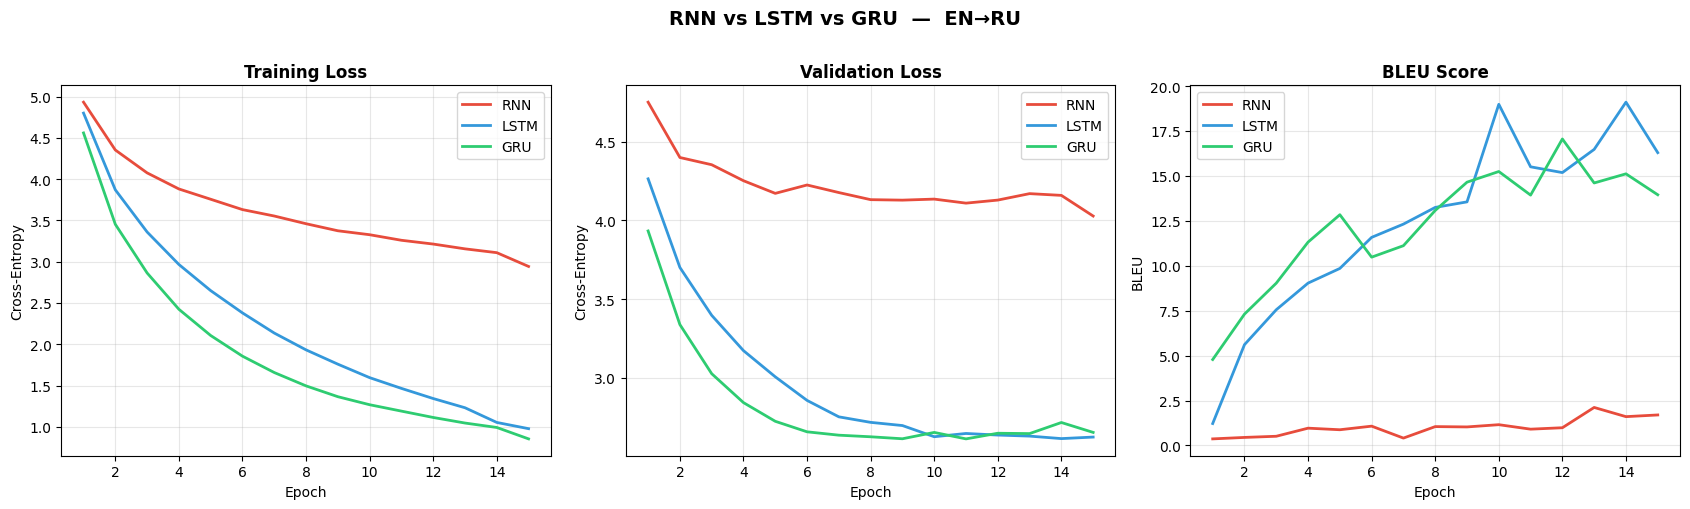


Model   BestValLoss      PPL   BestBLEU
----------------------------------------
RNN          4.0279    56.15       2.11
LSTM         2.6118    13.62      19.10
GRU          2.6100    13.60      17.05


In [10]:
colors = {'rnn': '#e74c3c', 'lstm': '#3498db', 'gru': '#2ecc71'}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
xs = range(1, EPOCHS+1)

for cell in ['rnn', 'lstm', 'gru']:
    c = colors[cell]
    axes[0].plot(xs, history[cell]['tr'],   label=cell.upper(), color=c, lw=2)
    axes[1].plot(xs, history[cell]['vl'],   label=cell.upper(), color=c, lw=2)
    axes[2].plot(xs, history[cell]['bleu'], label=cell.upper(), color=c, lw=2)

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Loss', 'BLEU Score'],
    ['Cross-Entropy', 'Cross-Entropy', 'BLEU']):
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('RNN vs LSTM vs GRU  —  EN→RU', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Model":<6} {"BestValLoss":>12} {"PPL":>8} {"BestBLEU":>10}')
print('-'*40)
for cell in ['rnn', 'lstm', 'gru']:
    bl = min(history[cell]['vl'])
    bb = max(history[cell]['bleu'])
    print(f'{cell.upper():<6} {bl:>12.4f} {math.exp(bl):>8.2f} {bb:>10.2f}')

In [11]:
tests = [
    'i love you .',
    'where is the bathroom ?',
    'she is reading a book .',
    'the weather is nice today .',
    'can you help me ?',
    'he does not know the answer .',
]

for sent in tests:
    toks = tokenize_en(sent)
    print(f'EN: {sent}')
    for cell in ['rnn', 'lstm', 'gru']:
        m = history[cell]['model']
        m.load_state_dict(torch.load(f'best_{cell}.pt', map_location=device))
        pred = translate(m, toks)
        print(f'  {cell.upper():4s}: {" ".join(pred)}')
    print()

EN: i love you .
  RNN : том говорит , что не не , чтобы я .
  LSTM: я люблю тебя .
  GRU : люблю тебя люблю тебя люблю .

EN: where is the bathroom ?
  RNN : том <UNK> , что не <UNK> в бостоне
  LSTM: где находится в пляж ?
  GRU : где находится в <UNK> <UNK> ?

EN: she is reading a book .
  RNN : давайте поедем на автобусе , <UNK> <UNK> .
  LSTM: она книгу книгу .
  GRU : она книгу книгу книгу книгу книгу .

EN: the weather is nice today .
  RNN : мэри не <UNK> <UNK> <UNK> <UNK> .
  LSTM: погода здесь очень <UNK> .
  GRU : сегодня погода сегодня сегодня погода .

EN: can you help me ?
  RNN : это ли ?
  LSTM: можешь помочь мне помочь ?
  GRU : вы можете помочь мне помочь ?

EN: he does not know the answer .
  RNN : мы <UNK> единственные , кто не , .
  LSTM: он не знает , как
  GRU : он знает , знает ответ ответа .



In [12]:
@torch.no_grad()
def beam_search(model, src_tokens, beam_width=4, max_len=50):
    model.eval()
    ids = src_vocab.encode(src_tokens) + [EOS_IDX]
    src = torch.tensor([ids], dtype=torch.long).to(device)
    _, enc_h = model.encoder(src)
    beams, done = [(0.0, [], enc_h)], []
    for _ in range(max_len):
        new_beams = []
        for lp, toks, h in beams:
            t_id = toks[-1] if toks else SOS_IDX
            tok  = torch.tensor([t_id]).to(device)
            logits, nh = model.decoder(tok, h)
            log_p = F.log_softmax(logits, -1).squeeze(0)
            for slp, sid in zip(*log_p.topk(beam_width)):
                sid = sid.item()
                if sid == EOS_IDX:
                    done.append(((lp + slp.item()) / max(len(toks), 1), toks))
                else:
                    new_beams.append((lp + slp.item(), toks + [sid], nh))
        beams = sorted(new_beams, key=lambda x: x[0]/max(len(x[1]),1), reverse=True)[:beam_width]
        if not beams: break
    if not done:
        done = [(b[0]/max(len(b[1]),1), b[1]) for b in beams]
    best = max(done, key=lambda x: x[0])
    return tgt_vocab.decode(best[1])

# Demo on LSTM
lstm_m = history['lstm']['model']
lstm_m.load_state_dict(torch.load('best_lstm.pt', map_location=device))
for sent in tests[:4]:
    toks = tokenize_en(sent)
    g = translate(lstm_m, toks)
    b = beam_search(lstm_m, toks)
    print(f'EN:     {sent}')
    print(f'Greedy: {" ".join(g)}')
    print(f'Beam-4: {" ".join(b)}')
    print()

EN:     i love you .
Greedy: я люблю тебя .
Beam-4: я люблю тебя люблю .

EN:     where is the bathroom ?
Greedy: где находится в пляж ?
Beam-4: где находится пляж ?

EN:     she is reading a book .
Greedy: она книгу книгу .
Beam-4: она пишет книгу книгу .

EN:     the weather is nice today .
Greedy: погода здесь очень <UNK> .
Beam-4: погода здесь очень <UNK> .

